I was experimenting with both the example HJ PT profiles given by PICASO and my specific science case

In [3]:
#Imports
import pandas as pd
import numpy as np
import os
#replace with ref file locations
os.environ["picaso_refdata"]="/Users/ihuckabee/Documents/picaso-master/reference"
os.environ['PYSYN_CDBS']="/Users/ihuckabee/Documents/picaso-master/grp/redcat/trds"
refdata = os.getenv("picaso_refdata")
import sys
sys.path.append("..")
from picaso import justdoit as jdi
from picaso import justplotit as jpi
from virga import justdoit as vdi
import pdb
import xarray as xr
import astropy.units as u
import matplotlib.pyplot as plt

## First, PICASO's HJ example

In [17]:
opacity = jdi.opannection(wave_range=[1,1.5])
#1D SET UP
case1d = jdi.inputs()
case1d.phase_angle(0) #radians
case1d.gravity(radius=1,radius_unit=jdi.u.Unit('R_jup'), mass=1, mass_unit=jdi.u.Unit('M_jup')) #any astropy units available
case1d.star(opacity, temp=5778, metal=0.00, logg=4.4374, semi_major = 30.178, semi_major_unit = u.Unit("au"), radius=1.0, radius_unit=jdi.u.R_sun,)
case1d.atmosphere(filename= jdi.HJ_pt(), delim_whitespace=True)
pt_1d = pd.read_csv(jdi.HJ_pt(), delim_whitespace=True)
# create coords
lon = np.linspace(-180,180,128)
lat = np.linspace(-90,90,64)
pres_1d = np.array(pt_1d['pressure'])
temp = np.array(pt_1d['temperature'])

array([1.10775685e-06, 1.35935639e-06, 1.66810054e-06, 2.04696827e-06,
       2.51188643e-06, 3.08239924e-06, 3.78248991e-06, 4.64158883e-06,
       5.69581081e-06, 6.98947321e-06, 8.57695899e-06, 1.05250029e-05,
       1.29154967e-05, 1.58489319e-05, 1.94486244e-05, 2.38658979e-05,
       2.92864456e-05, 3.59381366e-05, 4.41005945e-05, 5.41169527e-05,
       6.64082785e-05, 8.14912747e-05, 1.00000000e-04, 1.22712524e-04,
       1.50583635e-04, 1.84784980e-04, 2.26754313e-04, 2.78255940e-04,
       3.41454887e-04, 4.19007911e-04, 5.14175183e-04, 6.30957344e-04,
       7.74263683e-04, 9.50118507e-04, 1.16591440e-03, 1.43072299e-03,
       1.75567629e-03, 2.15443469e-03, 2.64376119e-03, 3.24422608e-03,
       3.98107171e-03, 4.88527357e-03, 5.99484250e-03, 7.35642254e-03,
       9.02725178e-03, 1.10775685e-02, 1.35935639e-02, 1.66810054e-02,
       2.04696827e-02, 2.51188643e-02, 3.08239924e-02, 3.78248991e-02,
       4.64158883e-02, 5.69581081e-02, 6.98947321e-02, 8.57695899e-02,
      

Hear me out. I'm going to pull out all the relevant chemistry from the 1D profile so that I can tile it into 3D (since the 3D profile example from PICASO doesn't exactly line up with the 1D) 

In [5]:
h2_1D = pt_1d['H2']; h_1D = pt_1d['H']; he_1D = pt_1d['He']; h2o_1D = pt_1d['H2O']; ch4_1D = pt_1d['CH4']; co_1D = pt_1d['CO']; nh3_1D = pt_1d['NH3']; n2_1D = pt_1d['N2']; h2s_1D = pt_1d['H2S'];fe_1D = pt_1d['Fe']; na_1D = pt_1d['Na']; k_1D = pt_1d['K']; co2_1D = pt_1d['CO2']; sio_1D = pt_1d['SiO'];  
for i in range(len(temp)):
        chemsum = h2_1D[i] + h_1D[i]+ he_1D[i] + h2o_1D[i]+ co_1D[i]+ h2s_1D[i]+ ch4_1D[i] + fe_1D[i]+ na_1D[i]+ k_1D[i]+ co2_1D[i] +  nh3_1D[i]
        remainder = 1-chemsum
        h2_1D[i] += remainder
h2_3D = np.tile(np.array(h2_1D), (len(lon), len(lat), 1))
h_3D = np.tile(np.array(h_1D), (len(lon), len(lat), 1))
he_3D = np.tile(np.array(he_1D), (len(lon), len(lat), 1))
h2o_3D = np.tile(np.array(h2o_1D), (len(lon), len(lat), 1))
co_3D = np.tile(np.array(co_1D), (len(lon), len(lat), 1))
h2s_3D = np.tile(np.array(h2s_1D), (len(lon), len(lat), 1))
ch4_3D = np.tile(np.array(ch4_1D), (len(lon), len(lat), 1))
fe_3D = np.tile(np.array(fe_1D), (len(lon), len(lat), 1))
na_3D = np.tile(np.array(na_1D), (len(lon), len(lat), 1))
k_3D = np.tile(np.array(k_1D), (len(lon), len(lat), 1))
co2_3D = np.tile(np.array(co2_1D), (len(lon), len(lat), 1))
temp_data = np.tile(np.array(temp), (len(lon), len(lat), 1))

Creating our PT and chemistry xarrays for the 3D

In [6]:
ds = xr.Dataset(
    data_vars=dict(
        temperature=(["lon", "lat","pressure"], temp_data,{'units': 'Kelvin'})#, required
        #kzz = (["x", "y","z"], gcm_out['kzz'])#could add other data components if wanted
    ),
    coords=dict(
        lon=(["lon"], lon,{'units': 'degrees'}),#required
        lat=(["lat"], lat,{'units': 'degrees'}),#required
        pressure=(["pressure"], pres_1d,{'units': 'bar'})#required*
    ),
    attrs=dict(description="coords with vectors"),
)
ds_chem = xr.Dataset(
    data_vars=dict(
        H2O=(["lon", "lat","pressure"], h2o_3D,{'units': 'v/v'}),
        H2=(["lon", "lat","pressure"], h2_3D,{'units': 'v/v'}),
        H=(["lon", "lat","pressure"], h_3D,{'units': 'v/v'}),
        He=(["lon", "lat","pressure"], he_3D,{'units': 'v/v'}),
        CO=(["lon", "lat","pressure"], co_3D,{'units': 'v/v'}),
        H2S=(["lon", "lat","pressure"], h2s_3D,{'units': 'v/v'}),
        Na=(["lon", "lat","pressure"], na_3D,{'units': 'v/v'}),
        K=(["lon", "lat","pressure"], k_3D,{'units': 'v/v'}),
        Fe=(["lon", "lat","pressure"], fe_3D,{'units': 'v/v'}),
        CH4=(["lon", "lat","pressure"], ch4_3D,{'units': 'v/v'}),
        CO2=(["lon", "lat","pressure"], co2_3D,{'units': 'v/v'}),
    ),
    coords=dict(
        lon=(["lon"], lon,{'units': 'degrees'}),#required
        lat=(["lat"], lat,{'units': 'degrees'}),#required
        pressure=(["pressure"], pres_1d,{'units': 'bar'})#required*
    ),
    attrs=dict(description="coords with vectors"),
)
all_gcm = ds.update(ds_chem)

Now we're going to make a fake cloud (following the PICASO tutorial for the 3D case)

In [9]:
# create coords
wno_grid = np.linspace(1e4/1.5,1e4/1,10)#cloud properties are defined on a wavenumber grid
#create box-band cloud model
fake_opd = np.zeros((len(lon), len(lat),len(pres_1d)-1, len(wno_grid))) # create fake data
fake_asymmetry_g0 = np.zeros((len(lon), len(lat),len(pres_1d)-1, len(wno_grid)))
fake_ssa_w0 =  np.zeros((len(lon), len(lat),len(pres_1d)-1, len(wno_grid)))
where_pres = np.where(((pres_1d<0.01) & (pres_1d>.001)))#creating a grey cloud band
opdex= 10
g0ex=0.8
w0ex=0.9
for ip in where_pres[0]:
    fake_opd[:,:,ip,:]= opdex #optical depth of 10 (>>1)
    fake_asymmetry_g0[:,:,ip,:]=g0ex
    fake_ssa_w0[:,:,ip,:]=w0ex
    
ds_cld= xr.Dataset(
    data_vars=dict(
        opd=(["lon", "lat","pressure","wno"], fake_opd,{'units': 'depth per layer'}),
        g0=(["lon", "lat","pressure","wno"], fake_asymmetry_g0,{'units': 'none'}),
        w0=(["lon", "lat","pressure","wno"], fake_ssa_w0,{'units': 'none'}),
    ),
    coords=dict(
        lon=(["lon"], lon,{'units': 'degrees'}),#required
        lat=(["lat"], lat,{'units': 'degrees'}),#required
        pressure=(["pressure"], pres_1d[:-1],{'units': 'bar'}),#required
        wno=(["wno"], wno_grid,{'units': 'cm^(-1)'})#required for clouds
    ),
    attrs=dict(description="coords with vectors"),
)


In [7]:
nwno = 10 
wno_grid = np.linspace(1e4/1.51,1e4/0.99,nwno)#cloud properties are defined on a wavenumber grid
#create box-band cloud model
fake_opd = np.zeros((len(lon), len(lat),len(pres_1d)-1, len(wno_grid))) # create fake data
fake_asymmetry_g0 = np.zeros((len(lon), len(lat),len(pres_1d)-1, len(wno_grid)))
fake_ssa_w0 =  np.zeros((len(lon), len(lat),len(pres_1d)-1, len(wno_grid)))
where_pres = np.where(((pres_1d<0.01) & (pres_1d>.001)))#creating a grey cloud band

#SIMPLE wavelength dependence added 
opd= np.linspace(0,10,nwno)
g0=np.linspace(0,0.8,nwno)
w0=np.linspace(0,0.9,nwno)

for ip in where_pres[0]:
    fake_opd[:,:,ip,:]= opd #optical depth of 10 (>>1)
    fake_asymmetry_g0[:,:,ip,:]=g0
    fake_ssa_w0[:,:,ip,:]=w0
    
ds_cld= xr.Dataset(
    data_vars=dict(
        opd=(["lon", "lat","pressure","wno"], fake_opd,{'units': 'depth per layer'}),
        g0=(["lon", "lat","pressure","wno"], fake_asymmetry_g0,{'units': 'none'}),
        w0=(["lon", "lat","pressure","wno"], fake_ssa_w0,{'units': 'none'}),
    ),
    coords=dict(
        lon=(["lon"], lon,{'units': 'degrees'}),#required
        lat=(["lat"], lat,{'units': 'degrees'}),#required
        pressure=(["pressure"], pres_1d[:-1],{'units': 'bar'}),#required
        wno=(["wno"], wno_grid,{'units': 'cm^(-1)'})#required for clouds
    ),
    attrs=dict(description="coords with vectors"),
)

In [8]:
#create 1d cld dataframe 

xr1d = ds_cld.isel(lon=0, lat=0).sortby('wno').sortby('pressure')
nlayer = len(xr1d.coords['pressure'].values)
df_cld = pd.DataFrame(dict(opd=[np.nan]*int(nlayer*nwno), g0=[np.nan]*int(nlayer*nwno),wavenumber=[np.nan]*int(nlayer*nwno), wno=[np.nan]*int(nlayer*nwno),
                       pressure=[np.nan]*int(nlayer*nwno)), index=[i for i in range(int(nlayer*nwno))])
ii=0
for i in xr1d.coords['pressure']: 
    for j in xr1d.coords['wno']:
        df_cld.loc[ii,'opd']=xr1d['opd'].sel(pressure=i, wno=j)
        df_cld.loc[ii,'g0']=xr1d['g0'].sel(pressure=i, wno=j)
        df_cld.loc[ii,'w0']=xr1d['w0'].sel(pressure=i, wno=j)
        df_cld.loc[ii,'pressure']=i
        df_cld.loc[ii,'wavenumber']=j
        ii+=1
case1d.clouds(df=df_cld.astype(float))

Creating fake cloud for the 1D (again, following PICASO tutorial)

In [15]:
df_cld= vdi.picaso_format_slab(0.01, opdex+np.zeros((len(wno_grid))), w0ex+np.zeros((len(wno_grid))), g0ex+np.zeros((len(wno_grid))), wno_grid, pres_1d[:-1],p_top=0.001)
case1d.clouds(df=df_cld.astype(float))

NameError: name 'opdex' is not defined

Now with the clouds and xarrays defined, setup 3D case (3x3 just to make it fast) 

In [9]:
case_3d = jdi.inputs()
case_3d.phase_angle(0, num_tangle=8, num_gangle=8) 
case_3d.atmosphere_3d(all_gcm, regrid=True, plot=False,verbose=False)
case_3d.clouds_3d(ds_cld,plot=False) 
case_3d.gravity(radius=1,radius_unit=jdi.u.Unit('R_jup'),
                mass=1, mass_unit=jdi.u.Unit('M_jup')) #any astropy units available
case_3d.star(opacity, temp=5778, metal=0.00, logg=4.4374, semi_major = 0.1, semi_major_unit = u.Unit("au"), radius=1.0, radius_unit=jdi.u.R_sun,)

/Users/ihuckabee/anaconda3/lib/python3.10/site-packages/esmpy/interface/loadESMF.py:82: VersionWarning: ESMF installation version 8.4.0, ESMPy version 8.4.1
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(
/Users/ihuckabee/anaconda3/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


verbose=True;regrid=True; Regridding 3D output to ngangle=8, ntangle=8, with phase=0.


/Users/ihuckabee/anaconda3/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/Users/ihuckabee/anaconda3/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/Users/ihuckabee/anaconda3/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/Users/ihuckabee/anaconda3/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/Users/ihuckabee/anaconda3/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array i

Now running and plotting both cases (in reflected since that's what my science case is)

In [10]:
out3d_cld = case_3d.spectrum(opacity,calculation='reflected',dimension='3d',full_output=True)
out1d_cld = case1d.spectrum(opacity, calculation='reflected')
wno_3d,alb_3d = jdi.mean_regrid(out3d_cld['wavenumber'],out3d_cld['albedo'],R=100)
wno_1d, alb_1d = jdi.mean_regrid(out1d_cld['wavenumber'] , out1d_cld['albedo'],R=100)

3d clouds
1d clouds


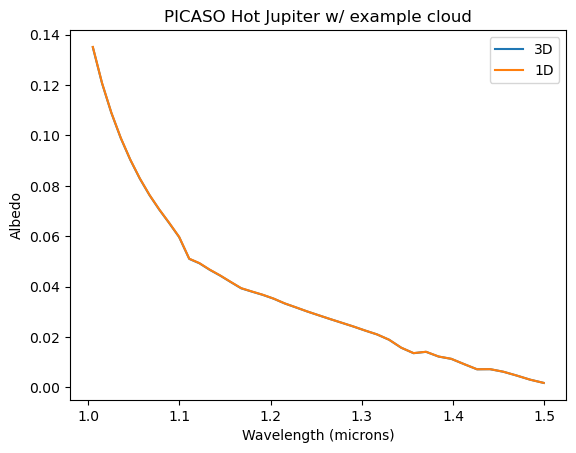

In [11]:
plt.close()
plt.plot(1e4/wno_3d,alb_3d, label = '3D')
plt.plot(1e4/wno_1d,alb_1d, label = '1D')
plt.title("PICASO Hot Jupiter w/ example cloud")
plt.xlabel("Wavelength (microns)")
plt.ylabel("Albedo")
plt.legend()
plt.show()

^^So something happened up there. It's a lot more obvious in this science case below:

## My specific science case that produced the weirdo plot

But first. all the file inputs I will eventually call 

In [14]:
nep_ptprofile = "./RefFiles/nepforpicaso_salr_abridged.txt"
nep_clouds = "./RefFiles/cloudall.csv"
hstspexdata = "./RefFiles/obsrefspec.txt"
cloudfree3d = "./RefFiles/3x3_cldfree.pic"
cloudfree1d = "./RefFiles/cloudfreespec.npy"
cloud1d = "./RefFiles/1Dcloudbase.npy"
cloud3d_3x3 = "./RefFiles/3x3_cldtest.pic"


Creating a simple 3x3 just so it goes fast (but the same problem happens with a 10x10)

In [15]:
opacity = jdi.opannection(wave_range=[0.3,2.5])
neptune = jdi.inputs()

#define spatial grid
grid_size = 3
neptune.phase_angle(0, num_gangle=grid_size, num_tangle=grid_size) #radians
neptune.gravity(radius=0.3463884070945,radius_unit=jdi.u.Unit('R_jup'), mass=0.053740779768177, mass_unit=jdi.u.Unit('M_jup'))
neptune.star(opacity, temp=5778, metal=0.00, logg=4.4374, semi_major = 30.178, semi_major_unit = u.Unit("au"), radius=1.0, radius_unit=jdi.u.R_sun,)

#PT profile
f = open(nep_ptprofile,'r')
lines = f.readlines()[1:]
pressure = []
temp = []
ch4 = []
h2s = []
for i in range(len(lines)):
        pressure.append(float(lines[i].split()[0]))
        temp.append(float(lines[i].split()[1]))
        ch4.append(float(lines[i].split()[2]))
        h2s.append(float(lines[i].split()[3]))

chem_other = 1 - np.array(ch4)+np.array(h2s)
h2 = 0.81*chem_other
he = 0.19*chem_other

#creating the lat and long grids for each species
pres = np.array(pressure) 
lon = np.linspace(-180,180,128)
lat = np.linspace(-90,90,64)
nep_data = np.tile(np.array(temp), (len(lon), len(lat), 1))
chem_ch4 = np.tile(np.array(ch4), (len(lon), len(lat), 1))
chem_h2s = np.tile(np.array(h2s), (len(lon), len(lat), 1))
chem_h2 = np.tile(np.array(h2), (len(lon), len(lat), 1))
chem_he = np.tile(np.array(he), (len(lon), len(lat), 1))
nwno = 24 
wno_grid = np.linspace(1e4/2.5,1e4/0.3,nwno)

array([9.74698e+02, 6.63626e+02, 4.51833e+02, 3.07632e+02, 2.09452e+02,
       1.42606e+02, 9.70940e+01, 6.61069e+01, 4.50091e+01, 3.06446e+01,
       2.08646e+01, 1.42057e+01, 9.67200e+00, 6.58521e+00, 4.48357e+00,
       3.05266e+00, 2.07841e+00, 1.41509e+00, 9.63471e-01, 6.55984e-01,
       4.46629e-01, 3.04089e-01, 2.07040e-01, 1.40964e-01, 9.59759e-02,
       6.53455e-02, 4.44907e-02, 3.02917e-02, 2.06242e-02, 1.40421e-02,
       9.56060e-03, 6.50937e-03, 4.43193e-03, 3.01749e-03, 2.05447e-03,
       1.39879e-03, 9.52375e-04, 6.48428e-04, 4.41485e-04, 3.00587e-04,
       2.04655e-04, 1.39340e-04, 9.48705e-05, 6.45929e-05, 4.39783e-05,
       2.99428e-05, 2.03867e-05, 1.38803e-05, 9.45048e-06, 6.43440e-06,
       4.38088e-06, 2.98274e-06, 2.03081e-06, 1.38268e-06, 9.41407e-07,
       6.40959e-07, 4.36400e-07, 2.97124e-07, 2.02298e-07, 1.37736e-07,
       9.37777e-08, 6.38489e-08, 4.34718e-08, 2.95979e-08, 2.01519e-08,
       1.37205e-08, 9.34163e-09])

clouds, setting up xarrays

In [24]:
#reading in cloud info calculated previously 
df_base = pd.read_csv(nep_clouds)
opd_array = np.zeros((len(lon), len(lat), len(pres)-1, nwno)); g0_array = np.zeros((len(lon), len(lat), len(pres)-1, nwno)); w0_array = np.zeros((len(lon), len(lat), len(pres)-1, nwno))

#iterate over each latitude and longitude point
opd_base = np.array(df_base['opd']).reshape(len(pres)-1,nwno)
g0_base= np.array(df_base['g0']).reshape(len(pres)-1,nwno)
w0_base = np.array(df_base['w0']).reshape(len(pres)-1,nwno)


#populate cloud param arrays to feed into xarray
for lo in range(len(lon)):
    for la in range(len(lat)):
        for press in range(len(pres)-1):
            for wave in range(nwno):
                opd_array[lo, la, press, wave] = opd_base[press][wave]
                g0_array[lo, la, press, wave] = g0_base[press][wave]
                w0_array[lo, la, press, wave] = w0_base[press][wave]
                
#setting up xarrays
ds = xr.Dataset(
    data_vars=dict(
        temperature=(["lon", "lat","pressure"], nep_data,{'units': 'Kelvin'})#, required
        #kzz = (["x", "y","z"], gcm_out['kzz'])#could add other data components if wanted
    ),
    coords=dict(
        lon=(["lon"], lon,{'units': 'degrees'}),#required
        lat=(["lat"], lat,{'units': 'degrees'}),#required
        pressure=(["pressure"], pres,{'units': 'bar'})#required*
    ),
    attrs=dict(description="coords with vectors"),
)

ds_chem = xr.Dataset(
    data_vars=dict(
        CH4=(["lon", "lat","pressure"], chem_ch4,{'units': 'v/v'}),
        H2S=(["lon", "lat","pressure"], chem_h2s,{'units': 'v/v'}),
        H2=(["lon", "lat","pressure"], chem_h2,{'units': 'v/v'}),
        He=(["lon", "lat","pressure"], chem_he,{'units': 'v/v'}),

    ),
    coords=dict(
        lon=(["lon"], lon,{'units': 'degrees'}),#required
        lat=(["lat"], lat,{'units': 'degrees'}),#required
        pressure=(["pressure"], pres,{'units': 'bar'})#required*
    ),
    attrs=dict(description="coords with vectors"),
)

ds_withchem= ds.update(ds_chem)

#adding in clouds

ds_cld= xr.Dataset(
    data_vars=dict(
        opd=(["lon", "lat","pressure","wno"], opd_array,{'units': 'depth per layer'}),
        g0=(["lon", "lat","pressure","wno"], g0_array,{'units': 'none'}),
        w0=(["lon", "lat","pressure","wno"], w0_array,{'units': 'none'}),
    ),
    coords=dict(
        lon=(["lon"], lon,{'units': 'degrees'}),#required
        lat=(["lat"], lat,{'units': 'degrees'}),#required
        pressure=(["pressure"], pres[:-1],{'units': 'bar'}),#required
        wno=(["wno"], wno_grid,{'units': 'cm^(-1)'})#required for clouds NEEDS CHEWCKING FOR UNITS AND WHATENOT. what do the 24 wv points map to
    ),
    attrs=dict(description="coords with vectors"),
)


In [25]:
neptune.atmosphere_3d(ds_withchem,regrid=True,plot=False,verbose=True)
neptune.clouds_3d(ds_cld, plot = False)
out3d = neptune.spectrum(opacity,calculation='reflected',dimension='3d',full_output=True)

wno_3d_cld,fpfs_3d_cld = out3d['full_output']['wavenumber'], out3d['fpfs_reflected'] #wno in cm^-1

verbose=True;regrid=True; Regridding 3D output to ngangle=3, ntangle=3, with phase=0.
verbose=True;regrid=True; Regridding 3D output to ngangle=3, ntangle=3, with phase=0.


/Users/ihuckabee/anaconda3/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/Users/ihuckabee/anaconda3/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/Users/ihuckabee/anaconda3/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/Users/ihuckabee/anaconda3/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/Users/ihuckabee/anaconda3/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array i

3d clouds


Plotting the data, the 1D versions of cloud and cloud free (created with PICASO using the same exact PT and cloud profile as fed in here), and a 3x3 cloud free

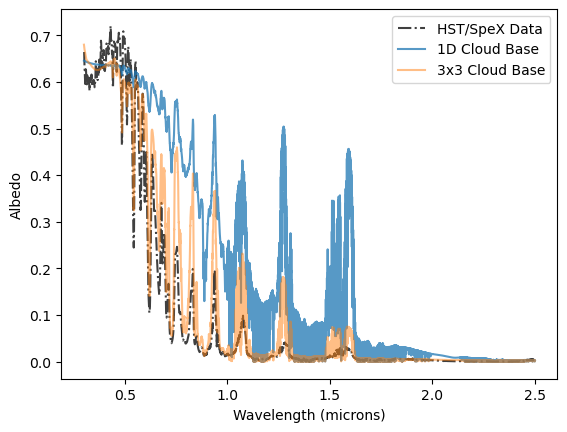

In [33]:
import pickle

#read in 3D spectrum output, native resolution
sm = 4.514565e12 #m
rp = 2.47639e7 #m


f = open("./RefFiles/obsrefspec.txt",'r')
lines = f.readlines()[110:] #data doesn't start til 0.3 microns
wv_obs = []; alb_obs = []
for i in range(len(lines)):
    wv_obs.append(float(lines[i].split()[0]))
    alb_obs.append(float(lines[i].split()[1]))

#convert to albedo
alb_3d_cld = fpfs_3d_cld*(sm/rp)**2

#read in 3x3 cloud free spectrum for comparison purposes 
infile = open(cloudfree3d, 'rb')
out3d = pickle.load(infile)
wno_3d,fpfs_3d = out3d[0],out3d[1]
alb_3d = fpfs_3d*(sm/rp)**2

#read in 3x3 cloud spec 
infile = open(cloud3d_3x3, 'rb')
out3d = pickle.load(infile)
wno_3d_8x8,fpfs_3d_8x8 = out3d[0],out3d[1]
alb_3d_8x8 = fpfs_3d_8x8*(sm/rp)**2

#read in 1D spectrum outputs, native resolution 
wno_1d, fpfs_1d = np.load(cloudfree1d)
wno_1dcld, fpfs_1dcld = np.load(cloud1d)
alb_1d = fpfs_1d*(sm/rp)**2
alb_1dcld = fpfs_1dcld*(sm/rp)**2

plt.plot(wv_obs,alb_obs, 'k-.', label="HST/SpeX Data", alpha = 0.75)
#plt.plot(1e4/wno_1d,alb_1d,label="1D Cloud Free", alpha = 0.75)
plt.plot(1e4/wno_1dcld,alb_1dcld,label="1D Cloud Base", alpha = 0.75)
plt.plot(1e4/wno_3d_cld,alb_3d_cld, label="3x3 Cloud Base", alpha = 0.5) #Also worth noting the 10x10 cloud base looks the same as the 3x3
#plt.plot(1e4/wno_3d_8x8,alb_3d_8x8, label="3x3 Cloud Base", alpha = 0.5) 
#plt.plot(1e4/wno_3d,alb_3d, label="3x3 Cloud Free", alpha = 0.5) 
plt.xlabel("Wavelength (microns)")
plt.ylabel("Albedo")
plt.legend()
plt.show()